# PEG PNIPAM Crystallization

In [190]:
def critical(x, A, x0, p, C):
    return A * 1 / np.abs(x - x0) ** p + C

array([2.42835325e+04, 3.14999666e+02, 2.82212574e+00, 8.19976298e+00])

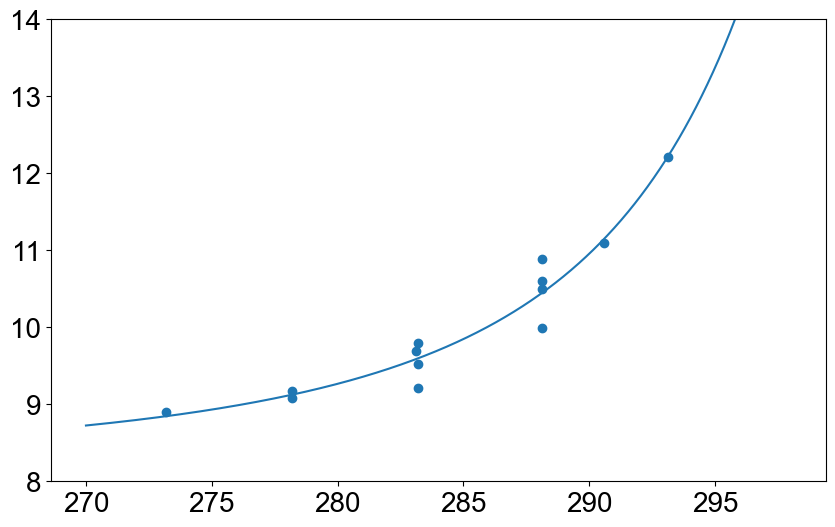

In [210]:

df = pd.read_csv(r"C:\Users\LabPCA\Desktop\plot-data (2).csv")

plt.scatter(df['x'], df[' y'])
# df[' y']

p0 = [15, 299, 0.8, 8]
p, cov = curve_fit(critical, np.array(df['x']), np.array(df[' y']), p0=p0, maxfev=10000, bounds=((0, 290, 0, 0), (np.inf, 315, np.inf, np.inf)))

lnsp = np.linspace(270, 298, 1000)
plt.plot(lnsp, critical(lnsp, *p))
plt.ylim(8, 14)
p

## Set up

In [1]:
%run ../../../setup_workspace.py # ../ means level up 
pi = np.pi
import scipy
import matplotlib.pyplot as plt
import numpy as np
from scipy.optimize import curve_fit
from matplotlib.ticker import ScalarFormatter

## Functions

In [2]:
def read_Samodelkin_info(path):
    df = pd.read_csv(path, sep='\t', index_col=0)
    return df[['Time', 'Temperature', 'Crystalinity', 'D 120', 'D 032', 'q1_Ampl']]

def Spheres_log_norm(x, scale, Ravg, p, bkg, I0, q0, s):
    return Polydisperse_spheres(x, scale, Ravg, p, bkg)+log_normal_peak(x, I0, q0, s)

def Spheres_norm(x, scale, Ravg, p, bkg, I0, q0, s):
    return Polydisperse_spheres(x, scale, Ravg, p, bkg)+normal_peak(x, I0, q0, s)

def Monodisperse_spheres(x, scale, R, SLD_sphere, SLD_solvent, bkg): #Scattering of a single homogeneous sphere
    ro = SLD_sphere - SLD_solvent
    V = 4 * np.pi * R**3
    return (scale / V) * (3*V*ro*(np.sin(x*R)-x*R*np.cos(x*R))/(x*R)**3)**2 + bkg
    
def Gaussian(R, sigma, Ravg):
    return 1/(sigma * np.sqrt(2*np.pi)) * np.exp((-1/(2*sigma**2)) * (R-Ravg)**2)

def Polydisperse_spheres(x, scale, Ravg, p, bkg):
    global counter 
    global sigma
    sigma = p*Ravg
    R = np.arange(max((Ravg - 3*sigma), 0.00001), Ravg + 3*sigma, 0.05)
    Iq = []
    for i in x:
        f = (Gaussian(R, sigma, Ravg) * (R**6)) * ((3*(np.sin(i*R) - i*R*np.cos(i*R))/(i*R)**3)**2) 
        Iq.append(scale* scipy.integrate.cumulative_trapezoid(f, R, dx = None, axis = 0)[-1] + bkg)
    return Iq

def log_normal_peak(q, I0, q0, s):
    return I0 * np.exp(-(np.log(q / q0))**2 / (2 * s**2))

def normal_peak(q, I0, q0, s):
    return I0 * np.exp(-(q - q0)**2 / (2 * s**2))

def normal_peak_C(q, I0, q0, s, C):
    return I0 * np.exp(-(q - q0)**2 / (2 * s**2)) + C

def average_1d_SAXS(Exp, frames):
    q, I = Exp.get_1d_SAXS()
    I *= 0
    for i in frames:
        q_frame, I_frame = Exp.get_1d_SAXS(i)
        I += I_frame
    I /= len(frames)
    return q, I

## Data

In [3]:
experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_SC5544\PEG_PNIPAM_292_6_Cryst_at_0C"
Exp292_6_0C = BM26_experiment(experiment_path)
Info292_6_0C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_292_6_Cryst_at_0.csv")

experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_SC5544\PEG_PNIPAM_292_6_Cryst_at_5C"
Exp292_6_5C = BM26_experiment(experiment_path)
Info292_6_5C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_292_6_Cryst_at_5C.csv")

experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_SC5544\PEG_PNIPAM_292_6_Cryst_at_10C"
Exp292_6_10C = BM26_experiment(experiment_path)
Info292_6_10C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_292_6_Cryst_at_10C.csv")

In [4]:
experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_SC5544\PEG_PNIPAM_292_12_Cryst_at_10C"
Exp292_12_10C = BM26_experiment(experiment_path)
Info292_12_10C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_292_12_Cryst_at_10C.csv")

experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_SC5544\PEG_PNIPAM_292_12_Cryst_at_15C"
Exp292_12_15C = BM26_experiment(experiment_path)
Info292_12_15C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_292_12_Cryst_at_15C.csv")

experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_SC5544\PEG_PNIPAM_292_12_Cryst_at_17_5C"
Exp292_12_17_5C = BM26_experiment(experiment_path)
Info292_12_17_5C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_292_12_Cryst_at_17_5C.csv")

In [5]:
experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_SC5544\PEG_PNIPAM_292_24_Cryst_at_10C"
Exp292_24_10C = BM26_experiment(experiment_path)
Info292_24_10C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_292_24_Cryst_at_10C.csv")

experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_SC5544\PEG_PNIPAM_292_24_Cryst_at_15C"
Exp292_24_15C = BM26_experiment(experiment_path)
Info292_24_15C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_292_24_Cryst_at_15C.csv")

experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_SC5544\PEG_PNIPAM_292_24_Cryst_at_20C"
Exp292_24_20C = BM26_experiment(experiment_path)
Info292_24_20C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_292_24_Cryst_at_20C.csv")

In [6]:
experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_July2024\PEG_PNIPAM_576_6_Cryst_0C"
Exp576_6_0C = BM26_experiment(experiment_path)
Info576_6_0C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_576_6_Cryst_at_0C.csv")

experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_July2024\PEG_PNIPAM_576_6_Cryst_10C"
Exp576_6_10C = BM26_experiment(experiment_path)
Info576_6_10C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_576_6_Cryst_at_10C.csv")

experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_July2024\PEG_PNIPAM_576_6_Cryst_15C"
Exp576_6_15C = BM26_experiment(experiment_path)
Info576_6_15C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_576_6_Cryst_at_15C.csv")

In [7]:
experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_July2024\PEG_PNIPAM_576_12_Cryst_5C"
Exp576_12_5C = BM26_experiment(experiment_path)
Info576_12_5C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_576_12_Cryst_at_5C.csv")

experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_July2024\PEG_PNIPAM_576_12_Cryst_10C"
Exp576_12_10C = BM26_experiment(experiment_path)
Info576_12_10C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_576_12_Cryst_at_10C.csv")

experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_July2024\PEG_PNIPAM_576_12_Cryst_15C"
Exp576_12_15C = BM26_experiment(experiment_path)
Info576_12_15C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_576_12_Cryst_at_15C.csv")

In [8]:
experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_SC5544\PEG_PNIPAM_576_24_Cryst_at_15C_bis"
Exp576_24_15C = BM26_experiment(experiment_path)
Info576_24_15C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_576_24_Cryst_at_15C_bis.csv")

experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_July2024\PEG_PNIPAM_576_24_Cryst_5C"
Exp576_24_5C = BM26_experiment(experiment_path)
Info576_24_5C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_576_24_Cryst_at_5C.csv")

experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_July2024\PEG_PNIPAM_576_24_Cryst_10C"
Exp576_24_10C = BM26_experiment(experiment_path)
Info576_24_10C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_576_24_Cryst_at_10C.csv")

experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_July2024\PEG_PNIPAM_576_24_Cryst_20C"
Exp576_24_20C = BM26_experiment(experiment_path)
Info576_24_20C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_576_24_Cryst_at_20C.csv")

In [9]:
experiment_path = r"E:\PEG_PNIPAM crystallization\BM26_SC5544\PEG_PNIPAM_888_24_Cryst_at_15C"
Exp888_24_15C = BM26_experiment(experiment_path)
Info888_24_15C = read_Samodelkin_info(r"E:\PEG_PNIPAM crystallization\Samodelkin data\general\results_cr_d1_sherer_PEG_PNIPAM_888_24_Cryst_at_15C.csv")


# Analysis

#### PDI comparison

Found 75 EDF files in SAXS


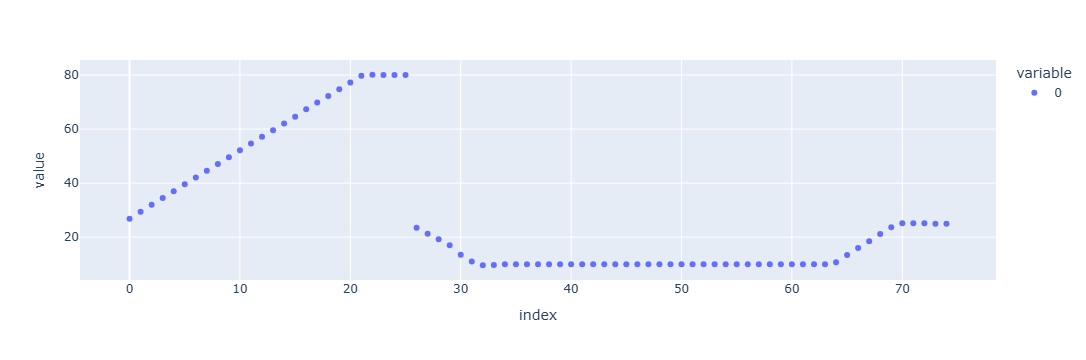

In [24]:
px.scatter(Exp292_12_10C.get_T_profile())

0.11426603230838693
0.1350691716789176


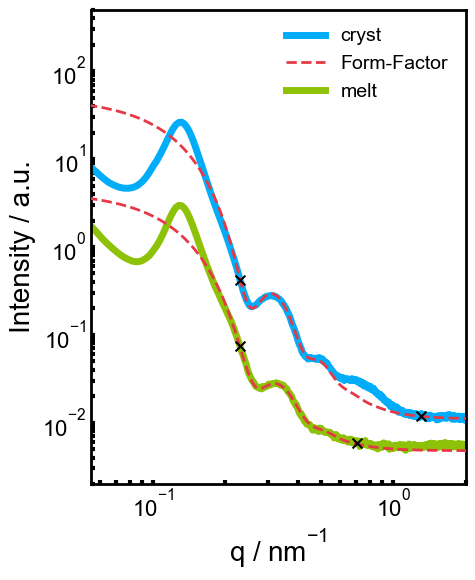

In [139]:
fig, ax = plt.subplots(figsize=(5, 6))
Data = Exp292_12_10C
ax.set_position([0.15, 0.11, 0.75, 0.79])  # [left, bottom, width, height]


### Crystal
q, I = Data.get_1d_SAXS(63)
ax.plot(q, I, linewidth=5, color='#01ADF8', label='cryst')
l = 65
r = 370
ax.scatter(q[l], I[l], marker='x', zorder=100, color='black', s=50)
ax.scatter(q[r], I[r], marker='x', zorder=100, color='black', s=50)

# Подгонка
p, cov = curve_fit(Spheres_log_norm, q[l:r], I[l:r], p0=[7.77852848e-07, 1.65942170e+01, 1.33242201e-01, 9.32162824e-03,
       3.61615147e-02, 7.99299489e-01, 2.97434579e-01], 
                   sigma=I[l:r]
                  )
print(p[2])

# ax.plot(q, Spheres_log_norm(q, *p), linestyle='--', color='black', zorder=15, label='Fit', linewidth=2)
ax.plot(q, Polydisperse_spheres(q, *p[:4]), linestyle='--', color='#e63946', zorder=11, label='Form-Factor', linewidth=2)
# ax.plot(q, log_normal_peak(q, *p[4:]) + p[3], linestyle='-', color='#a7c957', zorder=12, label='Log-Norm peak')

### MELT
q, I = Data.get_1d_SAXS(32)
q, I = q, I / 3
ax.plot(q, I, linewidth=5, color='#8EC209', label='melt')
l = 65
r = 200
ax.scatter(q[l], I[l], marker='x', zorder=100, color='black', s=50)
ax.scatter(q[r], I[r], marker='x', zorder=100, color='black', s=50)
p, cov = curve_fit(Polydisperse_spheres, q[l:r], I[l:r], p0=[7.77852848e-07, 1.65942170e+01, 1.33242201e-01, 9.32162824e-03], 
                   sigma=I[l:r]
                  )
ax.plot(q, Polydisperse_spheres(q, *p[:4]), linestyle='--', color='#e63946', zorder=11, linewidth=2)
print(p[2])
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'q / nm$^{-1}$', fontsize=20, fontfamily='Arial')
ax.set_ylabel(r'Intensity / a.u.', fontsize=20, fontfamily='Arial')
ax.set_xlim(0.06, 2)
ax.set_ylim(2e-3, 5e2)

ax.set_xlim(0.055, 2)
ax.set_ylim(2e-3, 5e2)

# Легенда
ax.legend(fontsize=14, frameon=False, fancybox=False, shadow=False)

# Утолщенные рамки
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)

# Настройка tick parameters
ax.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=16)

# Убедимся, что все tick labels используют Arial
for tick in ax.get_xticklabels():
    tick.set_fontfamily('Arial')
for tick in ax.get_yticklabels():
    tick.set_fontfamily('Arial')

# plt.tight_layout()
plt.savefig(r'E:\PEG_PNIPAM crystallization\Figures\Fig_PDI_a.png', dpi=300, bbox_inches='tight', transparent=True)


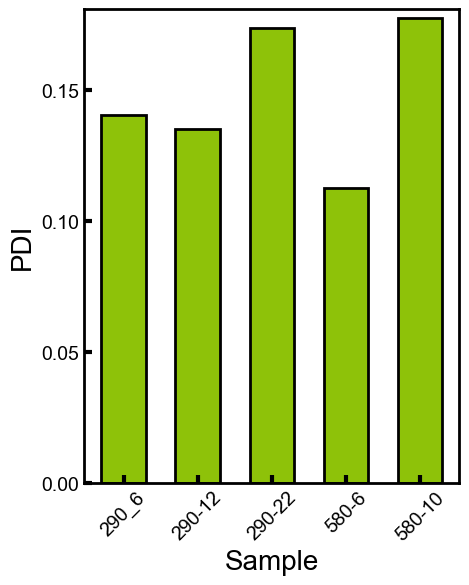

In [135]:
import matplotlib.pyplot as plt
import numpy as np

sample = ['290_6', '290-12', '290-22', '580-6', '580-10']
p_cryst = [0.12495989701878782, 0.11426603230838693, 0.15278871115007955, 0.10929041461585562, 0.1392453510025798]
p_melt = [0.1405424846635684, 0.1350691716789176, 0.17380347782563912, 0.11264095553365082, 0.1776951616832342]


fig, ax = plt.subplots(figsize=(5, 6))

# КОПИРУЕМ ГЕОМЕТРИЮ с графика I(q)
# Если у вас есть переменная ax из прошлого графика, можно сделать:
# ax.set_position(ax_old.get_position().bounds)

# Или задаем вручную те же значения, что были на I(q) графике
# (нужно знать точные значения с того графика)
ax.set_position([0.15, 0.11, 0.75, 0.79])  # [left, bottom, width, height]

# Bar plot
bars = ax.bar(sample, p_melt, color='#8EC209', edgecolor='black', linewidth=2, width=0.6)

# Labels
ax.set_xlabel('Sample', fontsize=20, fontfamily='Arial')
ax.set_ylabel('PDI', fontsize=20, fontfamily='Arial')

# Y-axis как на I(q) графике
ax.set_ylim(0, 0.181)

# Толстые рамки
for axis in ['top', 'bottom', 'left', 'right']:
    ax.spines[axis].set_linewidth(2)

# Tick parameters
ax.tick_params(axis="both", which='both', direction="in", width=3, length=6, labelsize=14)
ax.tick_params(axis='x', rotation=45)
ax.set_yticks([0, 0.05, 0.1, 0.15])

# Arial font
for tick in ax.get_xticklabels():
    tick.set_fontfamily('Arial')
for tick in ax.get_yticklabels():
    tick.set_fontfamily('Arial')

# ВАЖНО: НЕ используем tight_layout(), чтобы геометрия не сбилась
# plt.tight_layout()  # закомментировано!

plt.savefig(r'E:\PEG_PNIPAM crystallization\Figures\Fig_Melt_histogram.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

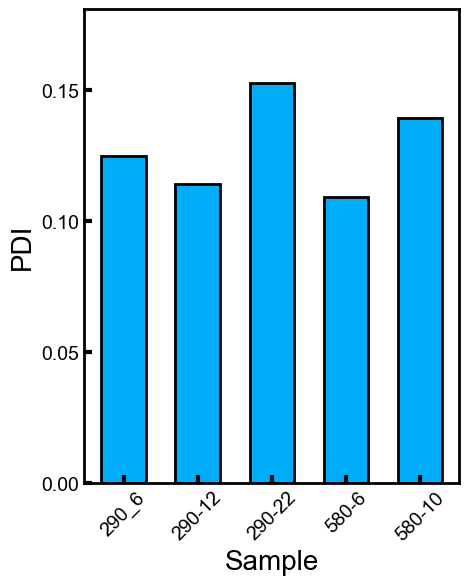

In [136]:
import matplotlib.pyplot as plt
import numpy as np

sample = ['290_6', '290-12', '290-22', '580-6', '580-10']
p_cryst = [0.12495989701878782, 0.11426603230838693, 0.15278871115007955, 0.10929041461585562, 0.1392453510025798]
p_melt = [0.1405424846635684, 0.1350691716789176, 0.17380347782563912, 0.11264095553365082, 0.1776951616832342]


fig, ax = plt.subplots(figsize=(5, 6))

# КОПИРУЕМ ГЕОМЕТРИЮ с графика I(q)
# Если у вас есть переменная ax из прошлого графика, можно сделать:
# ax.set_position(ax_old.get_position().bounds)

# Или задаем вручную те же значения, что были на I(q) графике
# (нужно знать точные значения с того графика)
ax.set_position([0.15, 0.11, 0.75, 0.79])  # [left, bottom, width, height]

# Bar plot
bars = ax.bar(sample, p_cryst, color='#01ADF8', edgecolor='black', linewidth=2, width=0.6)

# Labels
ax.set_xlabel('Sample', fontsize=20, fontfamily='Arial')
ax.set_ylabel('PDI', fontsize=20, fontfamily='Arial')

# Y-axis как на I(q) графике
ax.set_ylim(0, 0.181)

# Толстые рамки
for axis in ['top', 'bottom', 'left', 'right']:
    ax.spines[axis].set_linewidth(2)

# Tick parameters
ax.tick_params(axis="both", which='both', direction="in", width=3, length=6, labelsize=14)
ax.tick_params(axis='x', rotation=45)
ax.set_yticks([0, 0.05, 0.1, 0.15])

# Arial font
for tick in ax.get_xticklabels():
    tick.set_fontfamily('Arial')
for tick in ax.get_yticklabels():
    tick.set_fontfamily('Arial')

# ВАЖНО: НЕ используем tight_layout(), чтобы геометрия не сбилась
# plt.tight_layout()  # закомментировано!

plt.savefig(r'E:\PEG_PNIPAM crystallization\Figures\Fig_Cryst_histogram.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()

Found 98 EDF files in SAXS


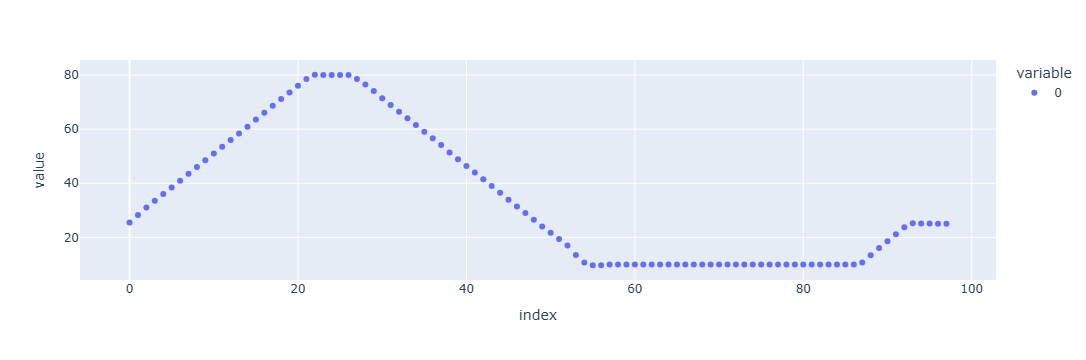

In [39]:
px.scatter(Exp292_6_10C.get_T_profile())


0.12495989701878782
0.1405424846635684


(0.002, 500.0)

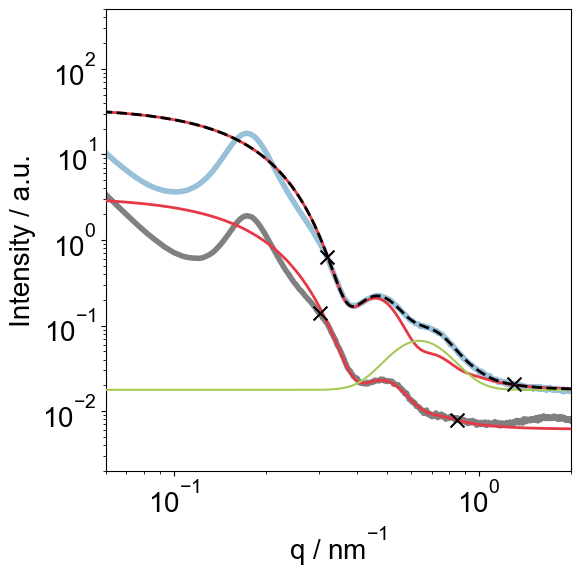

In [43]:
fig, ax = plt.subplots(figsize=(6, 6))
Data = Exp292_6_10C


### Crystal
q, I = Data.get_1d_SAXS(86)
ax.plot(q, I, linewidth=4, color='#98c1d9', label='I (q)')
l = 90
r = 370
ax.scatter(q[l], I[l], marker='x', zorder=100, color='black', s=100)
ax.scatter(q[r], I[r], marker='x', zorder=100, color='black', s=100)

# Подгонка
p, cov = curve_fit(Spheres_log_norm, q[l:r], I[l:r], p0=[7.77852848e-07, 11, 1.33242201e-01, 9.32162824e-03,
       3.61615147e-02, 7.99299489e-01, 2.97434579e-01], 
                   sigma=I[l:r]
                  )
print(p[2])

ax.plot(q, Spheres_log_norm(q, *p), linestyle='--', color='black', zorder=15, label='Fit', linewidth=2)
ax.plot(q, Polydisperse_spheres(q, *p[:4]), linestyle='-', color='#e63946', zorder=11, label='Form-Factor', linewidth=2)
ax.plot(q, log_normal_peak(q, *p[4:]) + p[3], linestyle='-', color='#a7c957', zorder=12, label='Log-Norm peak')

### MELT
q, I = Data.get_1d_SAXS(55)
q, I = q, I / 3
ax.plot(q, I, linewidth=4, color='grey', label='I (q)')
l = 85
r = 240
ax.scatter(q[l], I[l], marker='x', zorder=100, color='black', s=100)
ax.scatter(q[r], I[r], marker='x', zorder=100, color='black', s=100)
p, cov = curve_fit(Polydisperse_spheres, q[l:r], I[l:r], p0=[7.77852848e-07, 11, 1.33242201e-01, 9.32162824e-03], 
                   sigma=I[l:r]
                  )
ax.plot(q, Polydisperse_spheres(q, *p[:4]), linestyle='-', color='#e63946', zorder=11, label='Form-Factor', linewidth=2)
print(p[2])
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'q / nm$^{-1}$', fontsize=20, fontfamily='Arial')
ax.set_ylabel(r'Intensity / a.u.', fontsize=20, fontfamily='Arial')
ax.set_xlim(0.06, 2)
ax.set_ylim(2e-3, 5e2)

Found 76 EDF files in SAXS


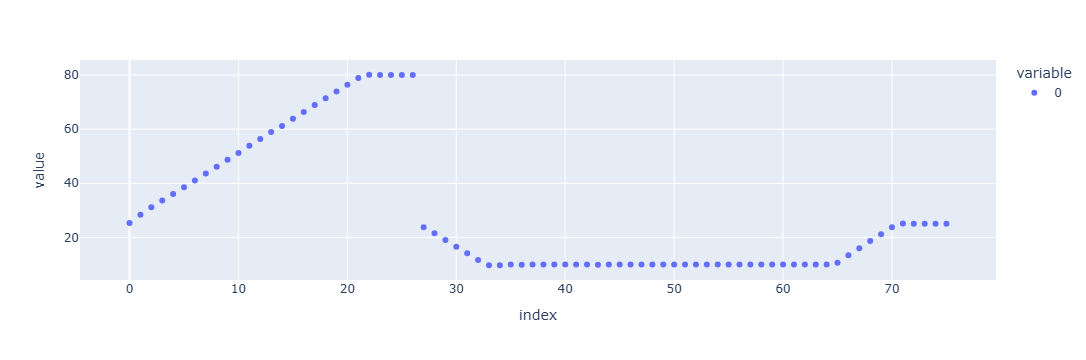

In [44]:
px.scatter(Exp292_24_10C.get_T_profile())


0.15278871115007955
0.17380347782563912


(0.002, 500.0)

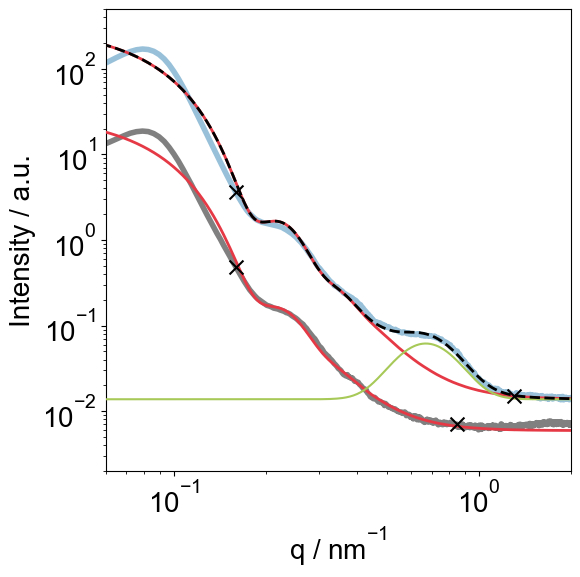

In [63]:
fig, ax = plt.subplots(figsize=(6, 6))
Data = Exp292_24_10C


### Crystal
q, I = Data.get_1d_SAXS(64)
ax.plot(q, I, linewidth=4, color='#98c1d9', label='I (q)')
l = 45
r = 370
ax.scatter(q[l], I[l], marker='x', zorder=100, color='black', s=100)
ax.scatter(q[r], I[r], marker='x', zorder=100, color='black', s=100)

# Подгонка
p, cov = curve_fit(Spheres_log_norm, q[l:r], I[l:r], p0=[7.77852848e-07, 21, 1.33242201e-01, 9.32162824e-03,
       3.61615147e-02, 7.99299489e-01, 2.97434579e-01], 
                   sigma=I[l:r]
                  )
print(p[2])

ax.plot(q, Spheres_log_norm(q, *p), linestyle='--', color='black', zorder=15, label='Fit', linewidth=2)
ax.plot(q, Polydisperse_spheres(q, *p[:4]), linestyle='-', color='#e63946', zorder=11, label='Form-Factor', linewidth=2)
ax.plot(q, log_normal_peak(q, *p[4:]) + p[3], linestyle='-', color='#a7c957', zorder=12, label='Log-Norm peak')

### MELT
q, I = Data.get_1d_SAXS(33)
q, I = q, I / 3
ax.plot(q, I, linewidth=4, color='grey', label='I (q)')
l = 45
r = 240
ax.scatter(q[l], I[l], marker='x', zorder=100, color='black', s=100)
ax.scatter(q[r], I[r], marker='x', zorder=100, color='black', s=100)
p, cov = curve_fit(Polydisperse_spheres, q[l:r], I[l:r], p0=[7.77852848e-07, 21, 1.33242201e-01, 9.32162824e-03], 
                   sigma=I[l:r]
                  )
ax.plot(q, Polydisperse_spheres(q, *p[:4]), linestyle='-', color='#e63946', zorder=11, label='Form-Factor', linewidth=2)
print(p[2])
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'q / nm$^{-1}$', fontsize=20, fontfamily='Arial')
ax.set_ylabel(r'Intensity / a.u.', fontsize=20, fontfamily='Arial')
ax.set_xlim(0.06, 2)
ax.set_ylim(2e-3, 5e2)

Found 203 EDF files in SAXS


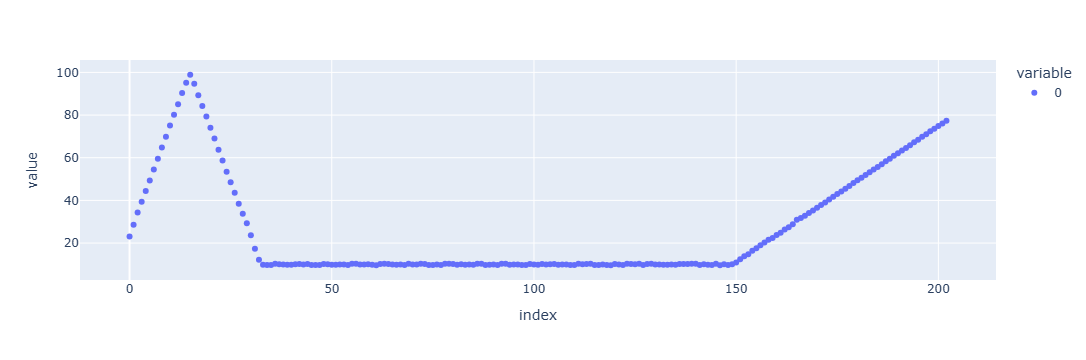

In [50]:
px.scatter(Exp576_6_10C.get_T_profile())


0.10929041461585562
0.11264095553365082


(0.002, 500.0)

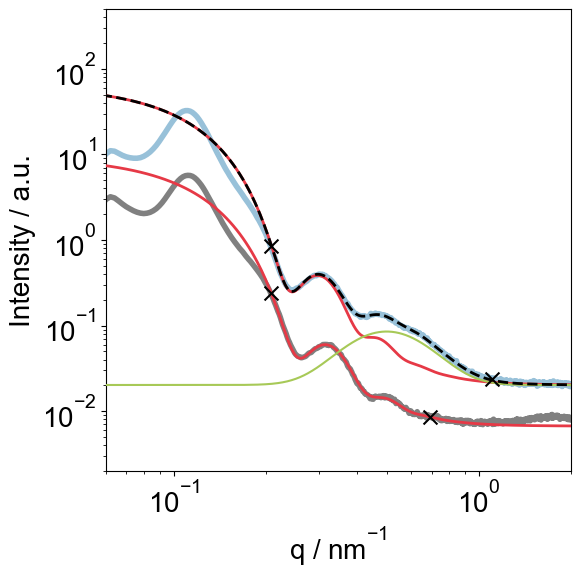

In [59]:
fig, ax = plt.subplots(figsize=(6, 6))
Data = Exp576_6_10C
fit = True

### Crystal
q, I = Data.get_1d_SAXS(148)
ax.plot(q, I, linewidth=4, color='#98c1d9', label='I (q)')
l = 105
r = 560
ax.scatter(q[l], I[l], marker='x', zorder=100, color='black', s=100)
ax.scatter(q[r], I[r], marker='x', zorder=100, color='black', s=100)

# Подгонка
if fit == True:
    p, cov = curve_fit(Spheres_log_norm, q[l:r], I[l:r], p0=[7.77852848e-07, 1.65942170e+01, 1.33242201e-01, 9.32162824e-03,
       3.61615147e-02, 7.99299489e-01, 2.97434579e-01], 
                       sigma=I[l:r]
                      )
    print(p[2])
    
    ax.plot(q, Spheres_log_norm(q, *p), linestyle='--', color='black', zorder=15, label='Fit', linewidth=2)
    ax.plot(q, Polydisperse_spheres(q, *p[:4]), linestyle='-', color='#e63946', zorder=11, label='Form-Factor', linewidth=2)
    ax.plot(q, log_normal_peak(q, *p[4:]) + p[3], linestyle='-', color='#a7c957', zorder=12, label='Log-Norm peak')

### MELT
q, I = Data.get_1d_SAXS(33)
q, I = q, I / 3
ax.plot(q, I, linewidth=4, color='grey', label='I (q)')
l = 105
r = 350
ax.scatter(q[l], I[l], marker='x', zorder=100, color='black', s=100)
ax.scatter(q[r], I[r], marker='x', zorder=100, color='black', s=100)

if fit == True:
    p, cov = curve_fit(Polydisperse_spheres, q[l:r], I[l:r], p0=[7.77852848e-07, 1.65942170e+01, 1.33242201e-01, 9.32162824e-03], 
                       sigma=I[l:r]
                      )
    ax.plot(q, Polydisperse_spheres(q, *p[:4]), linestyle='-', color='#e63946', zorder=11, label='Form-Factor', linewidth=2)
    print(p[2])
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'q / nm$^{-1}$', fontsize=20, fontfamily='Arial')
ax.set_ylabel(r'Intensity / a.u.', fontsize=20, fontfamily='Arial')
ax.set_xlim(0.06, 2)
ax.set_ylim(2e-3, 5e2)

Found 156 EDF files in SAXS


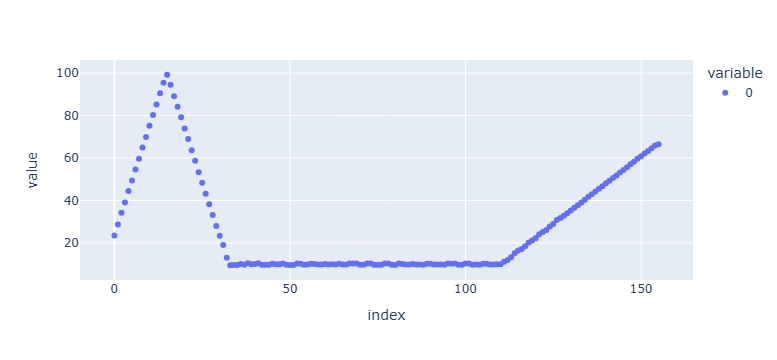

In [64]:
px.scatter(Exp576_24_10C.get_T_profile())


(0.002, 500.0)

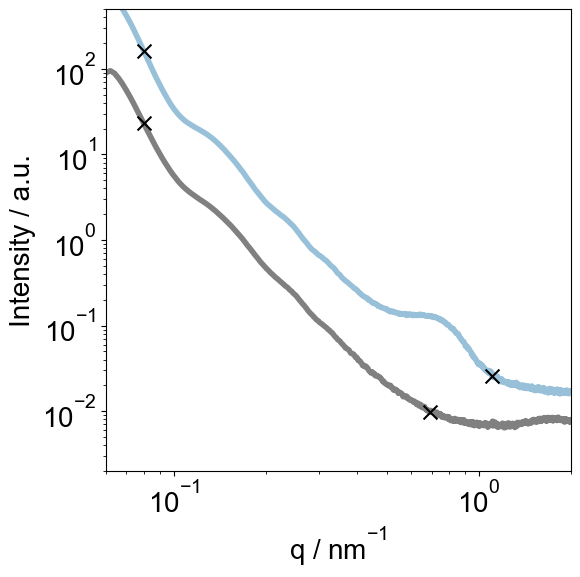

In [72]:
fig, ax = plt.subplots(figsize=(6, 6))
Data = Exp576_24_10C
fit = False

### Crystal
q, I = Data.get_1d_SAXS(108)
ax.plot(q, I, linewidth=4, color='#98c1d9', label='I (q)')
l = 40
r = 560
ax.scatter(q[l], I[l], marker='x', zorder=100, color='black', s=100)
ax.scatter(q[r], I[r], marker='x', zorder=100, color='black', s=100)

# Подгонка
if fit == True:
    p, cov = curve_fit(Spheres_log_norm, q[l:r], I[l:r], p0=[7.77852848e-07, 25, 1.33242201e-01, 9.32162824e-03,
       3.61615147e-02, 7.99299489e-01, 2.97434579e-01], 
                       sigma=I[l:r]
                      )
    print(p[2])
    
    ax.plot(q, Spheres_log_norm(q, *p), linestyle='--', color='black', zorder=15, label='Fit', linewidth=2)
    ax.plot(q, Polydisperse_spheres(q, *p[:4]), linestyle='-', color='#e63946', zorder=11, label='Form-Factor', linewidth=2)
    ax.plot(q, log_normal_peak(q, *p[4:]) + p[3], linestyle='-', color='#a7c957', zorder=12, label='Log-Norm peak')

### MELT
q, I = Data.get_1d_SAXS(33)
q, I = q, I / 3
ax.plot(q, I, linewidth=4, color='grey', label='I (q)')
l = 40
r = 350
ax.scatter(q[l], I[l], marker='x', zorder=100, color='black', s=100)
ax.scatter(q[r], I[r], marker='x', zorder=100, color='black', s=100)

if fit == True:
    p, cov = curve_fit(Polydisperse_spheres, q[l:r], I[l:r], p0=[7.77852848e-07, 25, 1.33242201e-01, 9.32162824e-03], 
                       sigma=I[l:r]
                      )
    ax.plot(q, Polydisperse_spheres(q, *p[:4]), linestyle='-', color='#e63946', zorder=11, label='Form-Factor', linewidth=2)
    print(p[2])
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'q / nm$^{-1}$', fontsize=20, fontfamily='Arial')
ax.set_ylabel(r'Intensity / a.u.', fontsize=20, fontfamily='Arial')
ax.set_xlim(0.06, 2)
ax.set_ylim(2e-3, 5e2)

Found 166 EDF files in SAXS


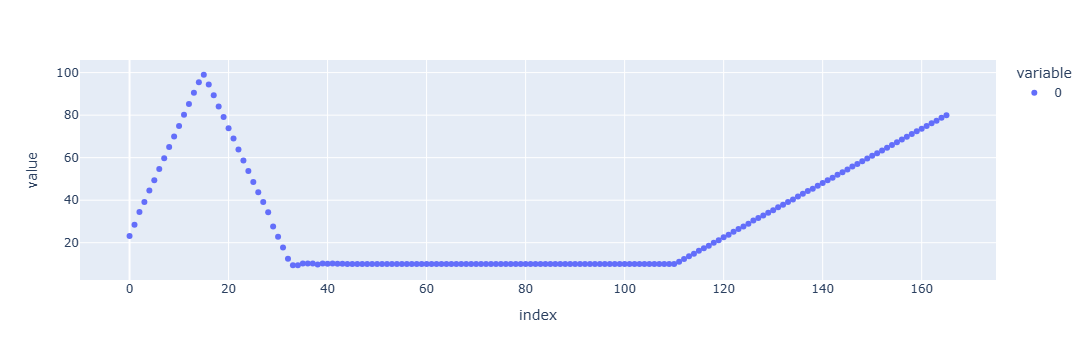

In [73]:
px.scatter(Exp576_12_10C.get_T_profile())


0.1392453510025798
0.1776951616832342


(0.002, 500.0)

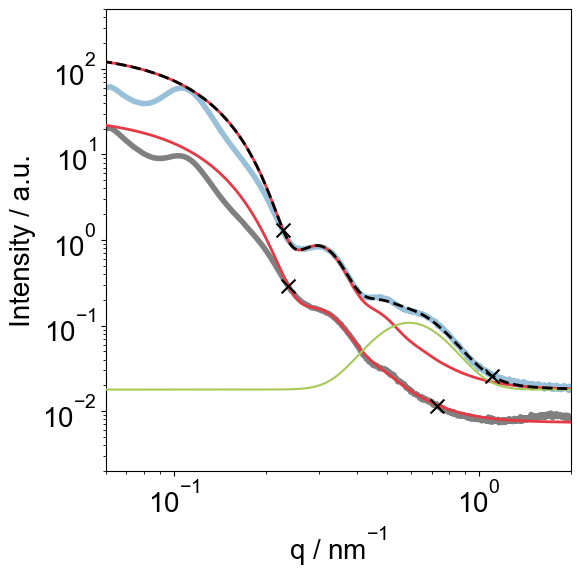

In [84]:
fig, ax = plt.subplots(figsize=(6, 6))
Data = Exp576_12_10C
fit = True

### Crystal
q, I = Data.get_1d_SAXS(110)
ax.plot(q, I, linewidth=4, color='#98c1d9', label='I (q)')
l = 115
r = 560
ax.scatter(q[l], I[l], marker='x', zorder=100, color='black', s=100)
ax.scatter(q[r], I[r], marker='x', zorder=100, color='black', s=100)

# Подгонка
if fit == True:
    p, cov = curve_fit(Spheres_log_norm, q[l:r], I[l:r], p0=[7.77852848e-07, 1.65942170e+01, 1.33242201e-01, 9.32162824e-03,
       3.61615147e-02, 7.99299489e-01, 2.97434579e-01], 
                       sigma=I[l:r]
                      )
    print(p[2])
    
    ax.plot(q, Spheres_log_norm(q, *p), linestyle='--', color='black', zorder=15, label='Fit', linewidth=2)
    ax.plot(q, Polydisperse_spheres(q, *p[:4]), linestyle='-', color='#e63946', zorder=11, label='Form-Factor', linewidth=2)
    ax.plot(q, log_normal_peak(q, *p[4:]) + p[3], linestyle='-', color='#a7c957', zorder=12, label='Log-Norm peak')

### MELT
q, I = Data.get_1d_SAXS(33)
q, I = q, I / 3
ax.plot(q, I, linewidth=4, color='grey', label='I (q)')
l = 120
r = 370
ax.scatter(q[l], I[l], marker='x', zorder=100, color='black', s=100)
ax.scatter(q[r], I[r], marker='x', zorder=100, color='black', s=100)

if fit == True:
    p, cov = curve_fit(Polydisperse_spheres, q[l:r], I[l:r], p0=[7.77852848e-07, 1.65942170e+01, 0.13, 9.32162824e-03], 
                       sigma=I[l:r]
                      )
    ax.plot(q, Polydisperse_spheres(q, *p[:4]), linestyle='-', color='#e63946', zorder=11, label='Form-Factor', linewidth=2)
    print(p[2])
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'q / nm$^{-1}$', fontsize=20, fontfamily='Arial')
ax.set_ylabel(r'Intensity / a.u.', fontsize=20, fontfamily='Arial')
ax.set_xlim(0.06, 2)
ax.set_ylim(2e-3, 5e2)

### Fit plot

In [17]:
plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial', 'DejaVu Sans']
plt.rcParams['mathtext.fontset'] = 'stix'
plt.rcParams['font.size'] = 20
plt.rcParams['mathtext.fontset'] = 'custom'
plt.rcParams['mathtext.it'] = 'Arial:italic'
plt.rcParams['mathtext.rm'] = 'Arial'
plt.rcParams['mathtext.tt'] = 'Arial'
plt.rcParams['mathtext.bf'] = 'Arial:bold'

### Fit

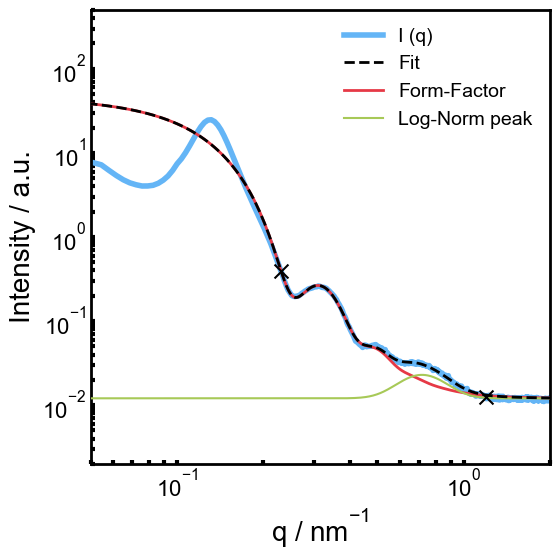

array([1.46200436e-06, 1.71955710e+01, 1.17988912e-01, 1.20531351e-02,
       1.08694206e-02, 7.15612566e-01, 1.78424899e-01])

In [19]:
# Создаем фигуру
fig, ax = plt.subplots(figsize=(6, 6))

# Данные
Data = Exp292_12_10C
q, I = Data.get_1d_SAXS(55)
ax.plot(q, I, linewidth=4, color='#64b5f6', label='I (q)')

# Маркеры для области подгонки
l = 65
r = 340
ax.scatter(q[l], I[l], marker='x', zorder=100, color='black', s=100)
ax.scatter(q[r], I[r], marker='x', zorder=100, color='black', s=100)

# Подгонка
p, cov = curve_fit(Spheres_log_norm, q[l:r], I[l:r], p0=[7.77852848e-07, 1.65942170e+01, 1.33242201e-01, 9.32162824e-03,
       3.61615147e-02, 7.99299489e-01, 2.97434579e-01])

# # Отображение компонентов подгонки
ax.plot(q, Spheres_log_norm(q, *p), linestyle='--', color='black', zorder=15, label='Fit', linewidth=2)
ax.plot(q, Polydisperse_spheres(q, *p[:4]), linestyle='-', color='#e63946', zorder=11, label='Form-Factor', linewidth=2)
ax.plot(q, log_normal_peak(q, *p[4:]) + p[3], linestyle='-', color='#a7c957', zorder=12, label='Log-Norm peak')

# # Настройки графика
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel(r'q / nm$^{-1}$', fontsize=20, fontfamily='Arial')
ax.set_ylabel(r'Intensity / a.u.', fontsize=20, fontfamily='Arial')
ax.set_xlim(0.05, 2)
ax.set_ylim(2e-3, 5e2)

# Легенда
ax.legend(fontsize=14, frameon=False, fancybox=False, shadow=False)

# Утолщенные рамки
for axis in ['top','bottom','left','right']:
    ax.spines[axis].set_linewidth(2)

# Настройка tick parameters
ax.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=16)

# Убедимся, что все tick labels используют Arial
for tick in ax.get_xticklabels():
    tick.set_fontfamily('Arial')
for tick in ax.get_yticklabels():
    tick.set_fontfamily('Arial')

plt.tight_layout()
# plt.savefig(r'E:\PEG_PNIPAM crystallization\Figures\Fig6.png', dpi=300, bbox_inches='tight', transparent=True)
plt.show()
p

Found 76 EDF files in SAXS


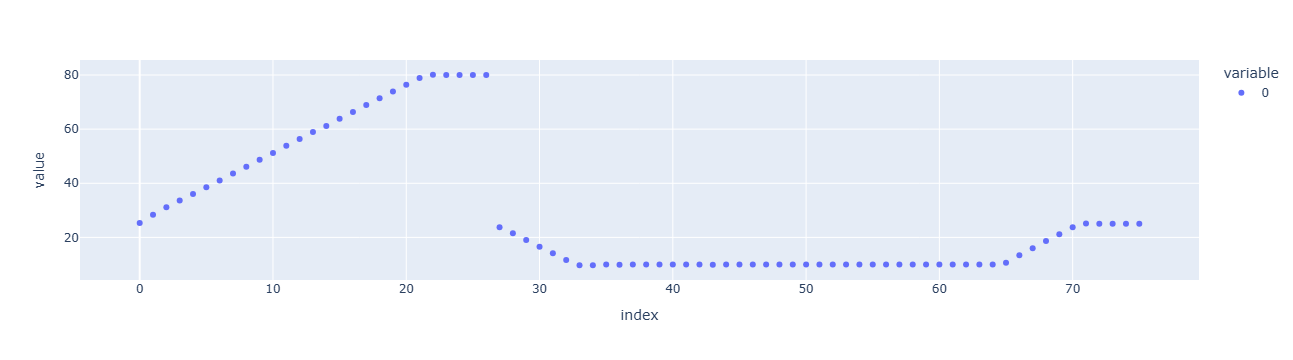

In [60]:
px.scatter(Exp292_24_10C.get_T_profile())

0.12605178726732807


array([1.20217248e-05, 1.15169798e+01, 1.26051787e-01, 1.75170477e-02,
       4.87873973e-02, 6.34435028e-01, 2.12603172e-01])

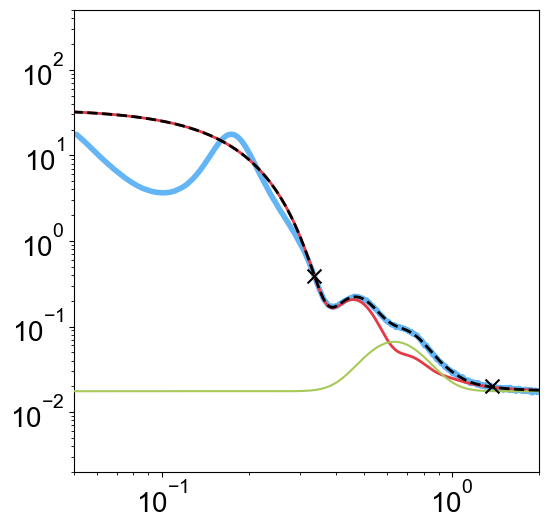

In [17]:
fig, ax = plt.subplots(figsize=(6, 6))

Data = Exp292_6_10C
q, I = Data.get_1d_SAXS(86)
ax.plot(q, I, linewidth=4, color='#64b5f6', label='I (q)')

# Маркеры для области подгонки
l = 95
r = 390
ax.scatter(q[l], I[l], marker='x', zorder=100, color='black', s=100)
ax.scatter(q[r], I[r], marker='x', zorder=100, color='black', s=100)

# # Подгонка
p0 = [1.20217253e-05, 1.15169798e+01, 1.26051782e-01, 1.75170479e-02,
       4.87873951e-02, 6.34435059e-01, 2.12603138e-01]
p, cov = curve_fit(Spheres_log_norm, q[l:r], I[l:r], p0=p0, maxfev = 2000, 
                   bounds=((0, 9, 0, 0, 0, 0.6, 0), 
                           (np.inf, 15, 0.3, np.inf,np.inf, 0.8,np.inf ))
                  )
# p = [1e-06, 17.8, 1.18357112e-01, 1e-2, 0.015, 0.65, 1.75849305e-01]
# # Отображение компонентов подгонки
ax.plot(q, Spheres_log_norm(q, *p), linestyle='--', color='black', zorder=15, label='Fit', linewidth=2)
ax.plot(q, Polydisperse_spheres(q, *p[:4]), linestyle='-', color='#e63946', zorder=11, label='Form-Factor', linewidth=2)
ax.plot(q, log_normal_peak(q, *p[4:]) + p[3], linestyle='-', color='#a7c957', zorder=12, label='Log-Norm peak')
ax.set_ylim(2e-3, 5e2)

ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlim(0.05, 2)
print(p[2])
p

##### 292_6_10

In [19]:
p0 = [1.20217253e-05, 1.15169798e+01, 1.26051782e-01, 1.75170479e-02,
       4.87873951e-02, 6.34435059e-01, 2.12603138e-01]
parameters = []

for i in range(28):
    print(i)
    q, I = Data.get_1d_SAXS(87 - i)
    p, cov = curve_fit(Spheres_log_norm, q[l:r], I[l:r], p0=p0, maxfev = 2000, 
                   bounds=((0, 9, 0, 0, 0, 0.6, 0), 
                           (np.inf, 15, 0.3, np.inf,np.inf, 0.8,np.inf ))
                  )

    parameters.append(p)
    p0 = p


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27


In [206]:
Spheres_log_norm

<function __main__.Spheres_log_norm(x, scale, Ravg, p, bkg, I0, q0, s)>

In [218]:
87 - 28

59

In [256]:
Info292_6_10C

,Time,Temperature,Crystalinity,D 120,D 032,q1_Ampl
Unnamed: 0,,,,,,
0,0,25.5,NaN,NaN,NaN,NaN
1,15,28.3,NaN,NaN,NaN,NaN
2,30,31.0,NaN,NaN,NaN,NaN
3,45,33.5,NaN,NaN,NaN,NaN
4,61,36.0,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...
93,2741,25.2,0.546842,25.142603,13.256383,NaN
94,2757,25.1,0.542308,25.363675,13.295706,NaN
95,2772,25.1,0.539823,25.406015,13.305304,NaN


In [21]:
parameters_292_6_10 = np.array(parameters)

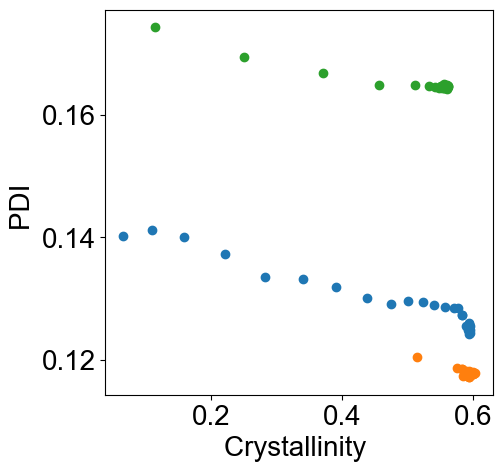

In [81]:

plt.figure(figsize=(5,5))

plt.ylabel('PDI ')
plt.xlabel('Crystallinity ')
plt.scatter(Info292_6_10C['Crystalinity'][87:59:-1], parameters_292_6_10.T[2])
plt.scatter(Info292_12_10C['Crystalinity'][63:36:-1], parameters_292_12_10.T[2])
plt.scatter(Info292_24_10C['Crystalinity'][63:35:-1], parameters_292_24_10.T[2])

### 292_12_10

In [76]:
p0 = [1.57295742e-06, 1.72179749e+01, 1.17853946e-01, 1.19915678e-02,
       9.07196927e-03, 7.15317996e-01, 1.77680477e-01]
parameters = []
Data = Exp292_12_10C

l = 65
r = 340 
for i in range(27):
    print(i)
    q, I = Data.get_1d_SAXS(63 - i)
    p, cov = curve_fit(Spheres_log_norm, q[l:r], I[l:r], p0=p0, maxfev = 2000, 
                   bounds=((0, 12, 0, 0, 0, 0.6, 0), 
                           (np.inf, 20, 0.3, np.inf,np.inf, 0.8,np.inf ))
                  )

    parameters.append(p)
    p0 = p 

0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26


In [77]:
parameters_292_12_10 = np.array(parameters)

### 292_24_10

In [79]:
p0 = [1.48367557e-06, 2.31806154e+01, 1.52679291e-01, 1.27178413e-02,
       4.75988386e-02, 6.65830441e-01, 2.17488395e-01]
parameters = []
l = 45
r = 330
Data = Exp292_24_10C

for i in range(28):
    print(i)
    q, I = Data.get_1d_SAXS(63
                            - i)
    p, cov = curve_fit(Spheres_log_norm, q[l:r], I[l:r], p0=p0, maxfev = 2000, 
                   bounds=((0, 19, 0, 0, 0, 0.6, 0), 
                           (np.inf, 25, 0.3, np.inf,np.inf, 0.8,np.inf ))
                  )

    parameters.append(p)
    p0 = p


0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27


In [80]:
parameters_292_24_10 = np.array(parameters)

### Curves

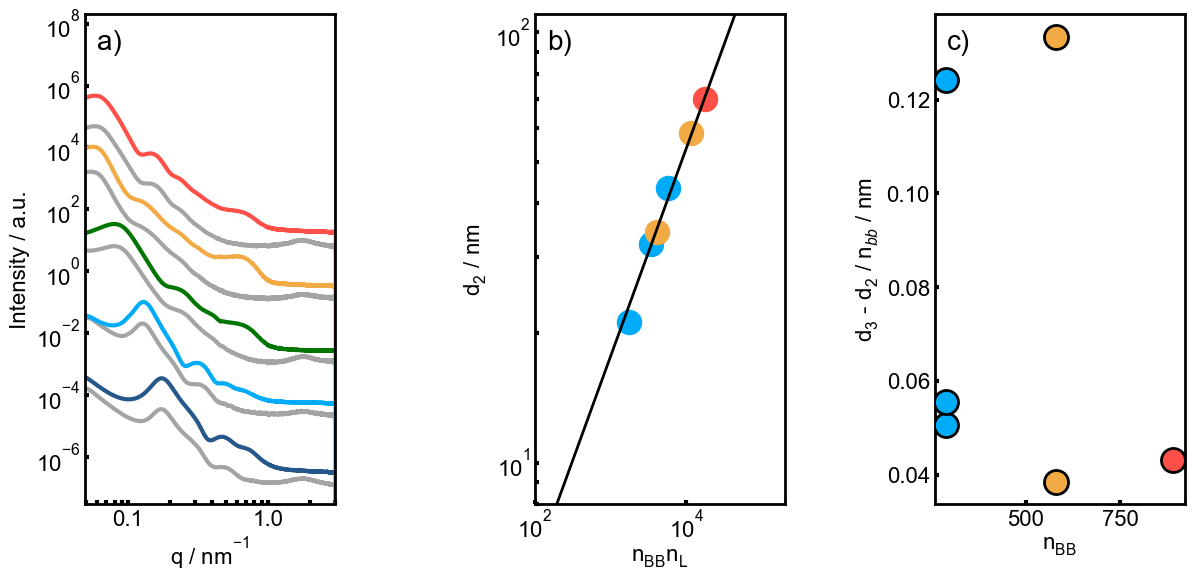

In [50]:
fig, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(10, 7))  # Увеличил ширину до 12 для трех графиков
fig.subplots_adjust(wspace=20)  # Уменьшил расстояние между графиками (было 20, что слишком много)

# Общие настройки
linewidth = 3

# ПЕРВЫЙ ГРАФИК (SAXS) - слева
ax1.set_position([0.06, 0.15, 0.28, 0.7])  # Немного сжал и сместил

# Данные для первого графика (ваш код без изменений)
grey_color = '#A4A4A4'

q, I = average_1d_SAXS(Exp888_24_15C, [9,10,11,12,13,14,15,16])
ax1.plot(q, (I-0.007)*1e3, linewidth=linewidth, color=grey_color)
q, I = average_1d_SAXS(Exp888_24_15C, [i for i in range(74, 84)])
ax1.plot(q, (I*1.5)*1e3, linewidth=linewidth, color='#FF4F49')

q, I = average_1d_SAXS(Exp576_24_15C, [6,7,8,9,10,11,12,13])
I[:68] += 8
I[68:73] += 10
ax1.plot(q, (I-0.009) / 60*1e3, linewidth=linewidth, color=grey_color)
q, I = average_1d_SAXS(Exp576_24_15C, [i for i in range(37, 47)])
ax1.plot(q, I / 40*1e3, linewidth=linewidth, color='#F2AA44')

q, I = average_1d_SAXS(Exp292_24_15C, [7,8,9,10,12,13])
ax1.plot(q, (I-0.009)/5000*1e3, linewidth=linewidth, color=grey_color)
q, I = average_1d_SAXS(Exp292_24_15C, [i for i in range(52, 62)])
ax1.plot(q, I/5000*1e3, linewidth=linewidth, color='#007500')

q, I = average_1d_SAXS(Exp292_12_15C, [14,15,16,17,18,19,20])
ax1.plot(q, (I-0.007)/200000*1e3, linewidth=linewidth, color=grey_color)
q, I = average_1d_SAXS(Exp292_12_15C, [i for i in range(42, 52)])
ax1.plot(q, I/200000*1e3, linewidth=linewidth, color='#00ABF8')

q, I = average_1d_SAXS(Exp292_6_10C, [35,36,37,38,39,40,41,42])
ax1.plot(q, (I-0.0075)/100000000*1e3, linewidth=linewidth, color=grey_color)
q, I = average_1d_SAXS(Exp292_6_10C, [i for i in range(83, 93)])
ax1.plot(q, I/50000000*1e3, linewidth=linewidth, color='#25578A')

# Настройки первого графика
ax1.semilogx()
ax1.semilogy()
ax1.set_xlim(0.049, 3)
ax1.set_ylim(3e-11*1e3, 2e5*1e3)

ax1.xaxis.set_major_formatter(ScalarFormatter())
ax1.set_xticks([0.1, 1])
ax1.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=16)  # Уменьшил размер шрифта
ax1.set_xlabel(r'q / nm$^{-1}$', fontsize=16, fontfamily='Arial')
ax1.set_ylabel(r'Intensity / a.u.', fontsize=16, fontfamily='Arial')

# Метка "a)" для первого графика
ax1.text(0.05, 0.97, 'a)', transform=ax1.transAxes, fontsize=20, 
         fontfamily='Arial', verticalalignment='top', horizontalalignment='left')

# Утолщенные рамки
for axis in ['top','bottom','left','right']:
    ax1.spines[axis].set_linewidth(2)

# ВТОРОЙ ГРАФИК (nBB nL) - центр
ax2.set_position([0.38, 0.15, 0.28, 0.7])  # Сместил в центр

# Настройки осей второго графика
ax2.semilogx()
ax2.semilogy()

ax2.set_xlabel(r'n$_{\mathrm{BB}}$n$_{\mathrm{L}}$', fontsize=16, fontfamily='Arial')
ax2.set_ylabel(r'd$_2$ / nm', fontsize=16, fontfamily='Arial')

ax2.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=16)
ax2.set_yticks([1e1, 1e2])
ax2.set_yticklabels(['$10^1$', '$10^2$'], fontsize=16)
ax2.set_ylim(0.8e1, 1.1e2)
ax2.set_xlim(1e2, 2e5)

# Данные для второго графика
X = np.zeros(6)
Y = np.zeros(6)

nBB = 290
nL = np.array([6,12,20])
x = nL * nBB
ax2.scatter(x, [21.2, 32.2, 43.5], s=300, color='#00ABF8', label='290')
X[:3] = x
Y[:3] = [21.2, 32.2, 43.5]

nBB = 580
nL = np.array([7,20])   
x = nL * nBB
ax2.scatter(x, [34.3, 58.2], s=300, color='#F2AA44', label='580')
X[3:5] = x
Y[3:5] = [34.3, 58.2]

nBB = 890
nL = np.array([20])   
x = nL * nBB
ax2.scatter(x, [69.9], s=300, color='#FF4F49', label='890')
X[5] = x[0]
Y[5] = 69.9

# Функция для аппроксимации
def power(x, a, b):
    return a * x**b

# Аппроксимация
p, cov = curve_fit(power, X, Y)
lnsp = np.linspace(1e2, max(X)*3)
ax2.plot(lnsp, power(lnsp, *p), color='black', linewidth=2)

# Метка "b)" для второго графика
ax2.text(0.05, 0.97, 'b)', transform=ax2.transAxes, fontsize=20, 
         fontfamily='Arial', verticalalignment='top', horizontalalignment='left')

# Утолщенные рамки
for axis in ['top','bottom','left','right']:
    ax2.spines[axis].set_linewidth(2)

# ТРЕТИЙ ГРАФИК (d3-d2 от nBB) - справа
ax3.set_position([0.70, 0.15, 0.28, 0.7])

# ВАШИ ДАННЫЕ ДЛЯ d3 (замените на реальные значения)
# Для каждого образца из второго графика должно быть соответствующее значение d3
# Структура та же, что и для d2:

# Для nBB=290, nL=[6,12,20]
d3_290_6 = 35.9  # значение d3 для nBB=290, nL=6
d3_290_12 = 48.3  # значение d3 для nBB=290, nL=12  
d3_290_20 = 79.5  # значение d3 для nBB=290, nL=20

# Для nBB=580, nL=[7,20]
d3_580_7 = 56.6   # значение d3 для nBB=580, nL=7
d3_580_20 = 135.6  # значение d3 для nBB=580, nL=20

# Для nBB=890, nL=[20]
d3_890_20 = 108.3  # значение d3 для nBB=890, nL=20

# Собираем все значения d3 в массив
d3_values = np.array([d3_290_6, d3_290_12, d3_290_20, d3_580_7, d3_580_20, d3_890_20])

# d2 значения из второго графика (уже есть)
d2_values = np.array([21.2, 32.2, 43.5, 34.3, 58.2, 69.9])

# nBB для каждого образца (повторяем для каждого nL)
nBB_all = np.array([290, 290, 290, 580, 580, 890])

# Вычисляем разницу
delta_d = (d3_values - d2_values) / nBB_all

# Строим график - точки с разными цветами в зависимости от nBB
colors = {'290': '#00ABF8', '580': '#F2AA44', '890': '#FF4F49'}

for nbb_val in np.unique(nBB_all):
    mask = nBB_all == nbb_val
    ax3.scatter(nBB_all[mask], delta_d[mask], s=300, 
                color=colors[str(int(nbb_val))], 
                edgecolor='black', 
                linewidth=2, zorder=5)
    
    # # Соединяем точки для одинакового nBB (если хотите показать тренд при разных nL)
    # ax3.plot(nBB_all[mask], delta_d[mask], 'o-', color=colors[str(int(nbb_val))], 
    #          linewidth=2, markersize=0)  # markersize=0 чтобы не рисовать маркеры повторно

# Опционально: среднее значение для каждого nBB
# for nbb_val in np.unique(nBB_all):
#     mask = nBB_all == nbb_val
#     mean_delta = np.mean(delta_d[mask])
#     ax3.scatter(nbb_val, mean_delta, s=400, color=colors[str(int(nbb_val))], 
#                 marker='s', edgecolor='black', linewidth=2, zorder=6)

# Настройки осей третьего графика
ax3.set_xlabel(r'n$_{\mathrm{BB}}$', fontsize=16, fontfamily='Arial')
ax3.set_ylabel(r'd$_3$ - d$_2$ / n$_{bb}$ / nm', fontsize=16, fontfamily='Arial')

ax3.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=16)

# Настройте лимиты в зависимости от ваших данных
# ax3.set_xlim(200, 1000)
# ax3.set_ylim(0, ...)

# Можно добавить легенду
# from matplotlib.lines import Line2D
# legend_elements = [Line2D([0], [0], 'o', color='#00ABF8', markerfacecolor='#00ABF8', 
#                           markersize=12, label='nBB=290', markeredgecolor='black', markeredgewidth=2),
#                    Line2D([0], [0], 'o', color='#F2AA44', markerfacecolor='#F2AA44', 
#                           markersize=12, label='nBB=580', markeredgecolor='black', markeredgewidth=2),
#                    Line2D([0], [0], 'o', color='#FF4F49', markerfacecolor='#FF4F49', 
#                           markersize=12, label='nBB=890', markeredgecolor='black', markeredgewidth=2)]
# ax3.legend(handles=legend_elements, fontsize=12, frameon=False, loc='best')

# Метка "c)" для третьего графика
ax3.text(0.05, 0.97, 'c)', transform=ax3.transAxes, fontsize=20, 
         fontfamily='Arial', verticalalignment='top', horizontalalignment='left')

# Утолщенные рамки
for axis in ['top','bottom','left','right']:
    ax3.spines[axis].set_linewidth(2)

# Сохраняем график
# plt.savefig(r'E:\PEG_PNIPAM crystallization\Figures\Fig3.png', dpi=300, bbox_inches='tight', transparent=True)
# plt.savefig(r'E:\PEG_PNIPAM crystallization\Figures\Fig3.pdf', bbox_inches='tight', transparent=True)
ax1.set_position([0.05, 0.15, 0.25, 0.7])  # ширина 0.26 вместо 0.28
ax2.set_position([0.5, 0.15, 0.25, 0.7])  # left сдвинут с 0.38 на 0.37  
ax3.set_position([0.9, 0.15, 0.25, 0.7])  # 

plt.show()

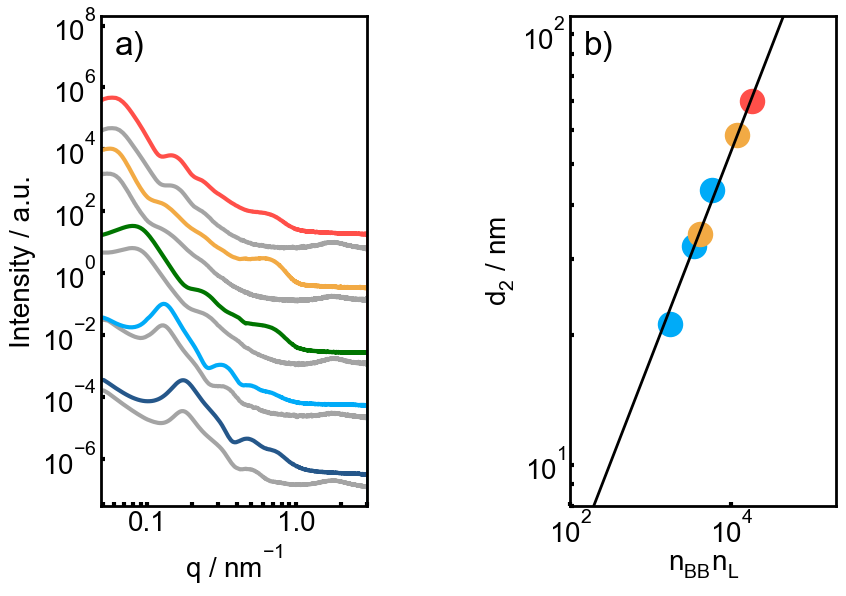

In [12]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(7, 7))
fig.subplots_adjust(wspace=20.)

# Общие настройки
linewidth = 3

# ПЕРВЫЙ ГРАФИК (SAXS) - слева
ax1.set_position([0.08, 0.15, 0.38, 0.7])

# Данные для первого графика
grey_color = '#A4A4A4'

q, I = average_1d_SAXS(Exp888_24_15C, [9,10,11,12,13,14,15,16])
ax1.plot(q, (I-0.007)*1e3, linewidth=linewidth, color=grey_color)
q, I = average_1d_SAXS(Exp888_24_15C, [i for i in range(74, 84)])
ax1.plot(q, (I*1.5)*1e3, linewidth=linewidth, color='#FF4F49')

q, I = average_1d_SAXS(Exp576_24_15C, [6,7,8,9,10,11,12,13])
I[:68] += 8
I[68:73] += 10
ax1.plot(q, (I-0.009) / 60*1e3, linewidth=linewidth, color=grey_color)
q, I = average_1d_SAXS(Exp576_24_15C, [i for i in range(37, 47)])
ax1.plot(q, I / 40*1e3, linewidth=linewidth, color='#F2AA44')

q, I = average_1d_SAXS(Exp292_24_15C, [7,8,9,10,12,13])
ax1.plot(q, (I-0.009)/5000*1e3, linewidth=linewidth, color=grey_color)
q, I = average_1d_SAXS(Exp292_24_15C, [i for i in range(52, 62)])
ax1.plot(q, I/5000*1e3, linewidth=linewidth, color='#007500')

q, I = average_1d_SAXS(Exp292_12_15C, [14,15,16,17,18,19,20])
ax1.plot(q, (I-0.007)/200000*1e3, linewidth=linewidth, color=grey_color)
q, I = average_1d_SAXS(Exp292_12_15C, [i for i in range(42, 52)])
ax1.plot(q, I/200000*1e3, linewidth=linewidth, color='#00ABF8')

q, I = average_1d_SAXS(Exp292_6_10C, [35,36,37,38,39,40,41,42])
ax1.plot(q, (I-0.0075)/100000000*1e3, linewidth=linewidth, color=grey_color)
q, I = average_1d_SAXS(Exp292_6_10C, [i for i in range(83, 93)])
ax1.plot(q, I/50000000*1e3, linewidth=linewidth, color='#25578A')

# Настройки первого графика
ax1.semilogx()
ax1.semilogy()
ax1.set_xlim(0.049, 3)
ax1.set_ylim(3e-11*1e3, 2e5*1e3)

ax1.xaxis.set_major_formatter(ScalarFormatter())
ax1.set_xticks([0.1, 1])
ax1.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=20)
ax1.set_xlabel(r'q / nm$^{-1}$', fontsize=20, fontfamily='Arial')
ax1.set_ylabel(r'Intensity / a.u.', fontsize=20, fontfamily='Arial')

# Метка "a)" для первого графика
ax1.text(0.05, 0.97, 'a)', transform=ax1.transAxes, fontsize=24, #fontweight='bold', 
         fontfamily='Arial', verticalalignment='top', horizontalalignment='left')

# Утолщенные рамки
for axis in ['top','bottom','left','right']:
    ax1.spines[axis].set_linewidth(2)

# ВТОРОЙ ГРАФИК (nBB nL) - справа
ax2.set_position([0.75, 0.15, 0.38, 0.7])

# Настройки осей второго графика
ax2.semilogx()
ax2.semilogy()

ax2.set_xlabel(r'n$_{\mathrm{BB}}$n$_{\mathrm{L}}$', fontsize=20, fontfamily='Arial')
ax2.set_ylabel(r'd$_2$ / nm', fontsize=20, fontfamily='Arial')

ax2.tick_params(axis="both", which='both', direction="in", width=3, length=3, labelsize=20)
ax2.set_yticks([1e1, 1e2])
ax2.set_yticklabels(['$10^1$', '$10^2$'], fontsize=20)
ax2.set_ylim(0.8e1, 1.1e2)
ax2.set_xlim(1e2, 2e5)

# Данные для второго графика
X = np.zeros(6)
Y = np.zeros(6)

nBB = 290
nL = np.array([6,12,20])
x = nL * nBB
ax2.scatter(x, [21.2, 32.2, 43.5], s=300, color='#00ABF8', label='290')
X[:3] = x
Y[:3] = [21.2, 32.2, 43.5]

nBB = 580
nL = np.array([7,20])   
x = nL * nBB
ax2.scatter(x, [34.3, 58.2], s=300, color='#F2AA44', label='580')
X[3:5] = x
Y[3:5] = [34.3, 58.2]

nBB = 890
nL = np.array([20])   
x = nL * nBB
ax2.scatter(x, [69.9], s=300, color='#FF4F49', label='890')
X[5] = x[0]
Y[5] = 69.9

# Функция для аппроксимации
def power(x, a, b):
    return a * x**b

# Аппроксимация
p, cov = curve_fit(power, X, Y)
lnsp = np.linspace(1e2, max(X)*3)
ax2.plot(lnsp, power(lnsp, *p), color='black', linewidth=2)

# Метка "b)" для второго графика
ax2.text(0.05, 0.97, 'b)', transform=ax2.transAxes, fontsize=24, #fontweight='bold', 
         fontfamily='Arial', verticalalignment='top', horizontalalignment='left')

# Утолщенные рамки
for axis in ['top','bottom','left','right']:
    ax2.spines[axis].set_linewidth(2)

# Легенда для второго графика
#ax2.legend(fontsize=0, frameon=False, prop={'family': 'Arial'}, loc=4)

# Сохраняем график
plt.savefig(r'E:\PEG_PNIPAM crystallization\Figures\Fig3.png', dpi=300, bbox_inches='tight', transparent=True)
#plt.savefig(r'E:\PEG_PNIPAM crystallization\Figures\Fig3.pdf', bbox_inches='tight', transparent=True)

plt.show()

# Crystallinity fit

### Avrami functions

In [118]:
def Avrami(x, A, k, n):
    return A * (1 - np.exp(-k * x ** n))

def Avrami_shifted(x, A, k, n, x0):
    res = Avrami(abs(x-x0), A, k, n)
    res[x < x0] *= 0
   
    return res
   
def Avraami_2(t, A, K1, n1, K2, n2):
    N = 300
    theta_arr = np.linspace(0, t, N)
 
    res = 0
 
    for theta in theta_arr:
        res += (1 - np.exp(-K2 * (t - theta) ** n2)) * theta ** (n1 - 1) * np.exp(-K1 * (theta ** n1)) * t / N
    return A * K1 * n1 * res
    
def Avraami_2_linspace(t,A, K1, n1, K2, n2):
    res = np.zeros(len(t))
 
    for i in range(len(t)):
        res[i] = Avraami_2(t[i],A, K1, n1, K2, n2)
    return res

def Model(t, A1, K1, n1, A2,  K2, n2):
    return Avrami(t, A1, K1, n1) + Avraami_2_linspace(t, A2, K1, n1, K2, n2)

### Results

array([2.98247619e-01, 3.15767977e-07, 2.45156792e+00, 3.26270283e-01,
       2.56394925e-04, 1.48659038e+00])

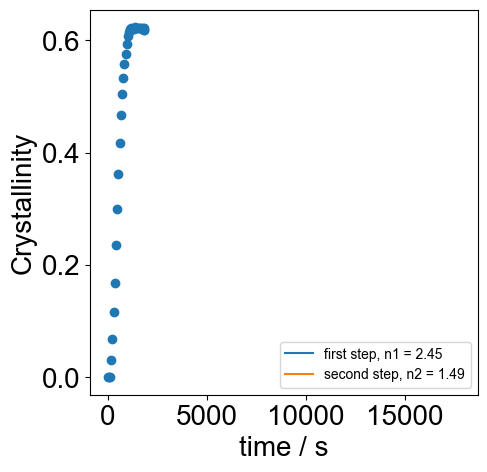

In [255]:
df = pd.read_csv(r"E:\PEG_PNIPAM crystallization\Samodelkin data\new_data\data_292_6_10.txt", sep=str('\t'), names=['time', 'BB', 'cr'], skiprows=1)

time = df['time']
BB = df['BB']
cr = df['cr']

plt.figure(figsize=(5,5))

# plt.scatter(time, 1 - BB)

p, cov = curve_fit(Avrami, time, 1-BB, p0=[1, 1e-8, 3])
# plt.plot(time, Avrami(time, *p))

K1 = p[1]
n1 = p[2]

plt.scatter(time, cr)

epsilon = 1e-10

bounds = ([0, K1 - epsilon, n1 - epsilon, 0, 0, 1], 
          [1, K1 + epsilon, n1 + epsilon, np.inf, np.inf, 2])

p0 = [0.3, K1, n1, 0.3, 0.00215978, 1.28298]

p, cov = curve_fit(Model, time[:-5], cr[:-5], bounds=bounds, p0=p0)

A1, A2, K2, n2 = p[0], p[3], p[4], p[5]

plt.plot(x, Avrami(x, A1, K1, n1), label=f'first step, n1 = {round(n1, 2)}')
plt.plot(x, Avraami_2_linspace(x, A2, K1, n1, K2, n2), label=f'second step, n2 = {round(n2,2)}')
plt.plot(x,  Model(x, A1, K1, n1, A2,  K2, n2))
plt.legend(fontsize=10)
plt.xlabel('time / s')
plt.ylabel('Crystallinity')


p

In [184]:
time[15]

np.int64(766)

array([3.23249467e-01, 6.25635604e-08, 3.08438223e+00, 3.85871851e-01,
       1.71633759e-03, 1.34700037e+00])

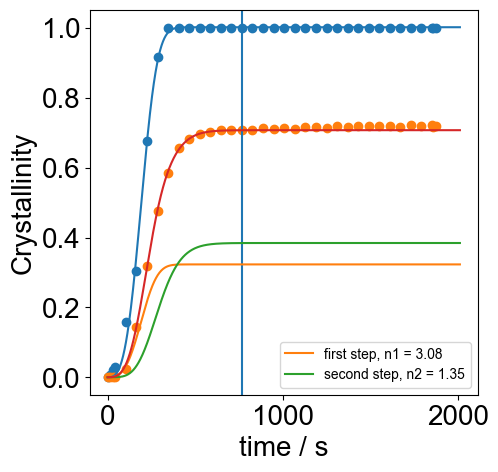

In [193]:
df = pd.read_csv(r"E:\PEG_PNIPAM crystallization\Samodelkin data\new_data\data_292_24_10 (1).txt", sep=str('\t'), names=['time', 'BB', 'cr'], skiprows=1)

time = df['time']
BB = df['BB']
cr = df['cr']

plt.figure(figsize=(5,5))

plt.scatter(time, 1 - BB)

p, cov = curve_fit(Avrami, time[:-20], 1-BB[:-20], p0=[1,  6.8594e-08, 3.06619])
plt.plot(x, Avrami(x, *p))

K1 = p[1]
n1 = p[2]

plt.scatter(time, cr)

epsilon = 1e-10

bounds = ([0, K1 - epsilon, n1 - epsilon, 0, 0, 0], 
          [1, K1 + epsilon, n1 + epsilon, np.inf, np.inf, 2])

p0 = [0.333906, K1, n1, 0.381534, 0.00215978, 1.28298]

p, cov = curve_fit(Model, time[:15], cr[:15], bounds=bounds, p0=p0)
plt.axvline(time[15])

A1, A2, K2, n2 = p[0], p[3], p[4], p[5]

plt.plot(x, Avrami(x, A1, K1, n1), label=f'first step, n1 = {round(n1, 2)}')
plt.plot(x, Avraami_2_linspace(x, A2, K1, n1, K2, n2), label=f'second step, n2 = {round(n2,2)}')
plt.plot(x, Model(x, *p))
plt.legend(fontsize=10)
plt.xlabel('time / s')
plt.ylabel('Crystallinity')


p

array([2.82828148e-01, 3.30103028e-07, 2.44355904e+00, 3.44366941e-01,
       6.51074538e-04, 1.32969204e+00])

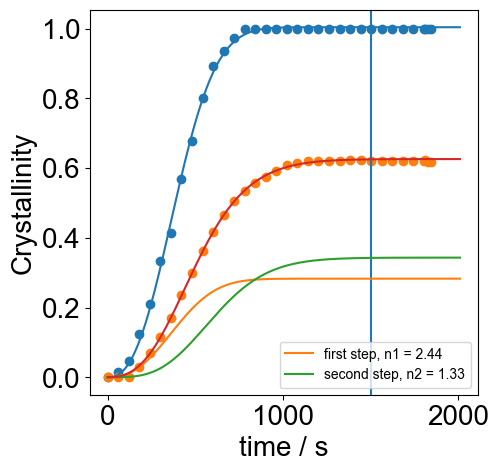

In [201]:
df = pd.read_csv(r"E:\PEG_PNIPAM crystallization\Samodelkin data\new_data\data_292_6_10 (1).txt", sep=str('\t'), names=['time', 'BB', 'cr'], skiprows=1)

time = df['time']
BB = df['BB']
cr = df['cr']

plt.figure(figsize=(5,5))

plt.scatter(time, 1 - BB)

point = 25

p, cov = curve_fit(Avrami, time[:point], 1-BB[:point], p0=[1,  6.8594e-08, 3.06619])
plt.plot(x, Avrami(x, *p))

K1 = p[1]
n1 = p[2]

plt.scatter(time, cr)

epsilon = 1e-10

bounds = ([0, K1 - epsilon, n1 - epsilon, 0, 0, 0], 
          [1, K1 + epsilon, n1 + epsilon, np.inf, np.inf, 2])

p0 = [0.333906, K1, n1, 0.381534, 0.00215978, 1.28298]

p, cov = curve_fit(Model, time[:point], cr[:point], bounds=bounds, p0=p0)
plt.axvline(time[point])

A1, A2, K2, n2 = p[0], p[3], p[4], p[5]

plt.plot(x, Avrami(x, A1, K1, n1), label=f'first step, n1 = {round(n1, 2)}')
plt.plot(x, Avraami_2_linspace(x, A2, K1, n1, K2, n2), label=f'second step, n2 = {round(n2,2)}')
plt.plot(x, Model(x, *p))
plt.legend(fontsize=10)
plt.xlabel('time / s')
plt.ylabel('Crystallinity')


p

Text(0, 0.5, 'Crystallinity')

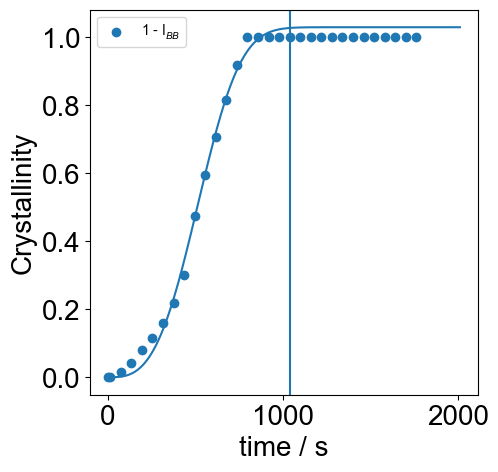

In [214]:
df = pd.read_csv(r"E:\PEG_PNIPAM crystallization\Samodelkin data\new_data\data_292_24_15 (1).txt", sep=str('\t'), names=['time', 'BB', 'cr'], skiprows=1)

time = df['time']
BB = df['BB']
cr = df['cr']

plt.figure(figsize=(5,5))

plt.scatter(time, 1 - BB, label='1 - I$_{BB}$')

point = 18

p, cov = curve_fit(Avrami, time[:point], 1-BB[:point], p0=[1,  6.8594e-08, 3.06619])
plt.plot(x, Avrami(x, *p))
plt.axvline(time[point])

# K1 = p[1]
# n1 = p[2]

# plt.scatter(time, cr)

# epsilon = 1e-10

# bounds = ([0, K1 - epsilon, n1 - epsilon, 0, 0, 0], 
#           [1, K1 + epsilon, n1 + epsilon, np.inf, np.inf, 2])

# p0 = [0.333906, K1, n1, 0.381534, 0.00215978, 1.28298]

# p, cov = curve_fit(Model, time[:point], cr[:point], bounds=bounds, p0=p0)


# A1, A2, K2, n2 = p[0], p[3], p[4], p[5]

# plt.plot(x, Avrami(x, A1, K1, n1), label=f'first step, n1 = {round(n1, 2)}')
# plt.plot(x, Avraami_2_linspace(x, A2, K1, n1, K2, n2), label=f'second step, n2 = {round(n2,2)}')
# plt.plot(x, Model(x, *p))
plt.legend(fontsize=10)
plt.xlabel('time / s')
plt.ylabel('Crystallinity')


# p